In [28]:
import pandas as pd
d=pd.read_csv('dataset.csv')

In [29]:
print(d.head())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [30]:
print(d.head(5))
print(d.tail(5))

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [31]:
print(d.info())
print(d.describe())
print(d.columns)
print(d.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
OrderID            1200 non-null object
Date               1200 non-null object
CustomerID         1200 non-null object
Product            1200 non-null object
Quantity           1200 non-null int64
UnitPrice          1200 non-null float64
ShippingAddress    1200 non-null object
PaymentMethod      1200 non-null object
OrderStatus        1200 non-null object
TrackingNumber     1200 non-null object
ItemsInCart        1200 non-null int64
CouponCode         891 non-null object
ReferralSource     1200 non-null object
TotalPrice         1200 non-null float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000 

In [32]:
print(d.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [33]:
# Missing values
print("Total Missing Values:", d.isnull().sum().sum())

Total Missing Values: 309


In [34]:

missing_percentage = (d.isnull().sum() / len(d)) * 100

print(missing_percentage.sort_values(ascending=False))

CouponCode         25.75
TotalPrice          0.00
ReferralSource      0.00
ItemsInCart         0.00
TrackingNumber      0.00
OrderStatus         0.00
PaymentMethod       0.00
ShippingAddress     0.00
UnitPrice           0.00
Quantity            0.00
Product             0.00
CustomerID          0.00
Date                0.00
OrderID             0.00
dtype: float64


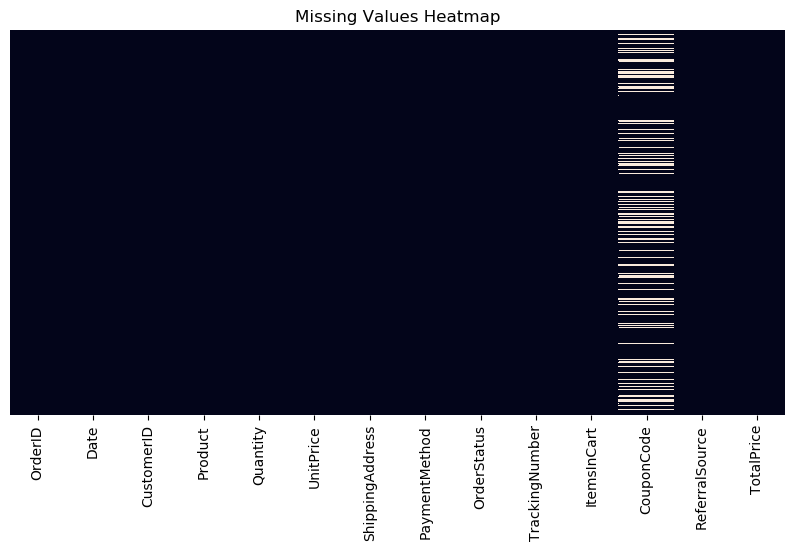

In [35]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(d.isnull(), cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

In [36]:

d['Coupon_Used'] = (
    d['CouponCode'] != 'No Coupon'
).astype(int)

In [38]:

d['Tracking_Available'] = (
    d['TrackingNumber'] != 'Not Assigned'
).astype(int)

In [9]:
# Handling numerical columns
d['Quantity'].fillna(d['Quantity'].median(), inplace=True)
d['ItemsInCart'].fillna(d['ItemsInCart'].median(), inplace=True)
d['TotalPrice'].fillna(d['TotalPrice'].median(), inplace=True)

In [12]:
# Handling categorical columns
d['Product'].fillna(d['Product'].mode()[0], inplace=True)
d['PaymentMethod'].fillna(d['PaymentMethod'].mode()[0], inplace=True)
d['CustomerID'].fillna(d['CustomerID'].mode()[0], inplace=True)

In [14]:
d['CouponCode'].fillna(d['CouponCode'].mode()[0], inplace=True)

In [15]:
print(d.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [19]:
d['TotalPrice'].fillna(d['TotalPrice'].median(), inplace=True)

In [39]:
d['Date'] = pd.to_datetime(d['Date'])

In [40]:

d.to_csv("newdataset.csv", index=False)